# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A linear model is linear in its parameters (coefficients). This means the coefficients enter the model only through addition and multiplication. The model is written as a linear combination (a weighted sum) of the variables. Even if the variables themselves are nonlinear (like $x^2$ or $\log(x)$), the model is still considered linear as long as it is linear with respect to the coefficients.

2. A dummy variable coefficient shows the difference in the outcome compared to a reference group. When we include an intercept and drop one category (to avoid the "dummy variable trap"), the intercept represents the mean of the reference group. Each dummy coefficient measures how much that specific group differs from the reference group on average.

3. Linear regression can be used for classification by applying a cutoff like 0.5. However, it is not a good choice because predictions are not restricted between 0 and 1, which can produce invalid probability values. Also, linear regression is very sensitive to outliers, which can shift the decision boundary and lead to poor results.

4. Overfitting happens when a model is too complex and learns random noise instead of the real pattern. The model fits the training data very well but performs poorly on new, unseen data. This usually means the model has high variance, meaning it is too sensitive to the specific data it was trained on.

5. Multicollinearity occurs when independent variables are highly correlated and explain the same variation in the outcome. In a two-stage sense, these variables "compete" to explain the same signal, leaving very little unique variation for each variable. This makes the coefficients unstable and noisy, leading to high model variance.

6. Linear models cannot capture nonlinear patterns directly in their original form. However, we can include polynomial terms (like $x^2$) or interaction terms (like $x_1 \cdot x_2$) to handle this. These transformations allow the model to fit more complex, curvy relationships while still staying within a linear framework.

7. The slope coefficient shows how much the outcome changes when the predictor increases by one unit, holding all other variables constant. This interpretation assumes that the model "controls" for the effects of the other variables included in the regression.

8. A train/test split divides the data only once, so the result depends heavily on that single random split. In contrast, k-fold cross validation splits the data into $k$ parts and repeats the process $k$ times. This uses all the data for both training and validation, providing a more reliable and stable estimate of model performance.

9. The value of $k$ is chosen to balance computation time and stability. Common choices are 5 or 10, as they usually provide a good balance between bias and variance. Larger values of $k$ give more stable results but take much more time to compute.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [10]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Q1_clean.csv')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [39]:
df = df.rename(columns={
    'Price': 'price',
    'Review Scores Rating': 'review_score',
    'Neighbourhood ': 'neighbourhood'
})

In [42]:
group_means = df.groupby('neighbourhood')[['price', 'review_score']].mean()
group_means

,price,review_score
neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


On average, Manhattan has the highest price among all neighbourhoods. The average review scores are similar across neighbourhoods, with only small differences.

In [40]:
df.columns

Index(['price', 'review_score', 'neighbourhood', 'Property Type', 'Room Type'], dtype='object')

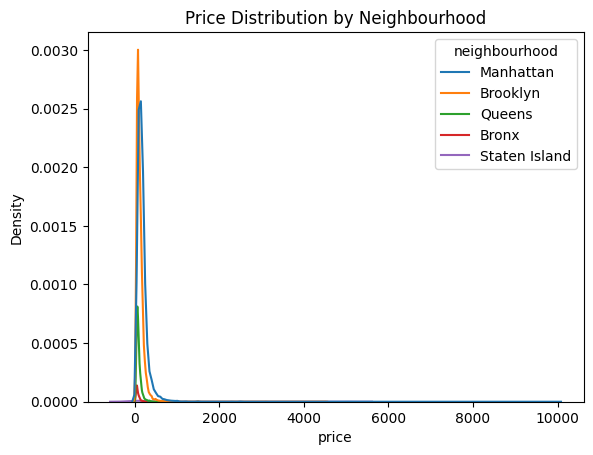

In [41]:
sns.kdeplot(data=df, x='price', hue='neighbourhood')
plt.title('Price Distribution by Neighbourhood')
plt.show()

The price distribution is highly right-skewed, with a long tail of very expensive listings. Most listings are concentrated at lower price levels, but there are a few very high-priced observations that stretch the distribution.

On average, Manhattan tends to have higher prices compared to other neighbourhoods, while boroughs like the Bronx and Staten Island have lower price distributions.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
